<a href="https://colab.research.google.com/github/marcohinojosag/IA_MKTR/blob/branch-L/cod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importación de librerias y carga del dataset
Quien necesita descargar en 2025, las APIs son el futuro 🗣🗣🗣

In [292]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from kagglehub import KaggleDatasetAdapter

In [293]:
# Sets path
test_path = "aps_failure_test_set.csv"
train_path = "aps_failure_training_set.csv"

# Load the latest version
test = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  test_path,
)

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "uciml/aps-failure-at-scania-trucks-data-set",
  train_path,
)

Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.
Using Colab cache for faster access to the 'aps-failure-at-scania-trucks-data-set' dataset.


# 1. Analisis del dataset


In [294]:
# Muestra de los datos
print(df.head(5))

  class  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [295]:
# Tamaño del dataset
print(df.shape)

(60000, 171)


Como que 60k filas 💀, que diga...

Descripcion de las columnas:
- clase: "neg" indica fallo en el sistema APS, "pos" todo en orden. (se renombra por palabra reservada)
- aa_000, ab_000, ac_000, ..., eg_000: atributos de entrada, sin un significado en particular (anonimos)

In [296]:
# Columnas del dataset
df.rename(columns={'class': 'clase'}, inplace=True)
df.columns

Index(['clase', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000',
       'ag_000', 'ag_001', 'ag_002',
       ...
       'ee_002', 'ee_003', 'ee_004', 'ee_005', 'ee_006', 'ee_007', 'ee_008',
       'ee_009', 'ef_000', 'eg_000'],
      dtype='object', length=171)

In [297]:
# Cantidad de elementos vacios por cada columna
cant_vacios = (df == "na").sum()
cant_vacios = cant_vacios[cant_vacios > 0]
print(cant_vacios)

ab_000    46329
ac_000     3335
ad_000    14861
ae_000     2500
af_000     2500
          ...  
ee_007      671
ee_008      671
ee_009      671
ef_000     2724
eg_000     2723
Length: 169, dtype: int64


In [298]:
# Cantidad de positivos y negativos del dataset
cant_neg = len(df[df.clase == 'neg'])
cant_pos = len(df[df.clase == 'pos'])
print(f"Negativos: {cant_neg}, Positivos: {cant_pos}")

Negativos: 59000, Positivos: 1000


# 2. Preprocesamiento del dataset

In [299]:
df_neg = df[df['clase'] == 'neg']
df_pos = df[df['clase'] == 'pos']
print(df_neg.head(5))

  clase  aa_000 ab_000      ac_000 ad_000 ae_000 af_000 ag_000 ag_001 ag_002  \
0   neg   76698     na  2130706438    280      0      0      0      0      0   
1   neg   33058     na           0     na      0      0      0      0      0   
2   neg   41040     na         228    100      0      0      0      0      0   
3   neg      12      0          70     66      0     10      0      0      0   
4   neg   60874     na        1368    458      0      0      0      0      0   

   ...   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  ee_008 ee_009 ef_000  \
0  ...  1240520  493384  721044  469792  339156  157956   73224      0      0   
1  ...   421400  178064  293306  245416  133654   81140   97576   1500      0   
2  ...   277378  159812  423992  409564  320746  158022   95128    514      0   
3  ...      240      46      58      44      10       0       0      0      4   
4  ...   622012  229790  405298  347188  286954  311560  433954   1218      0   

  eg_000  
0      0  
1      0  

In [300]:
cv = (df == "na").sum()/len(df)
cv_neg = (df_neg == "na").sum()/cant_neg
cv_pos = (df_pos == "na").sum()/cant_pos

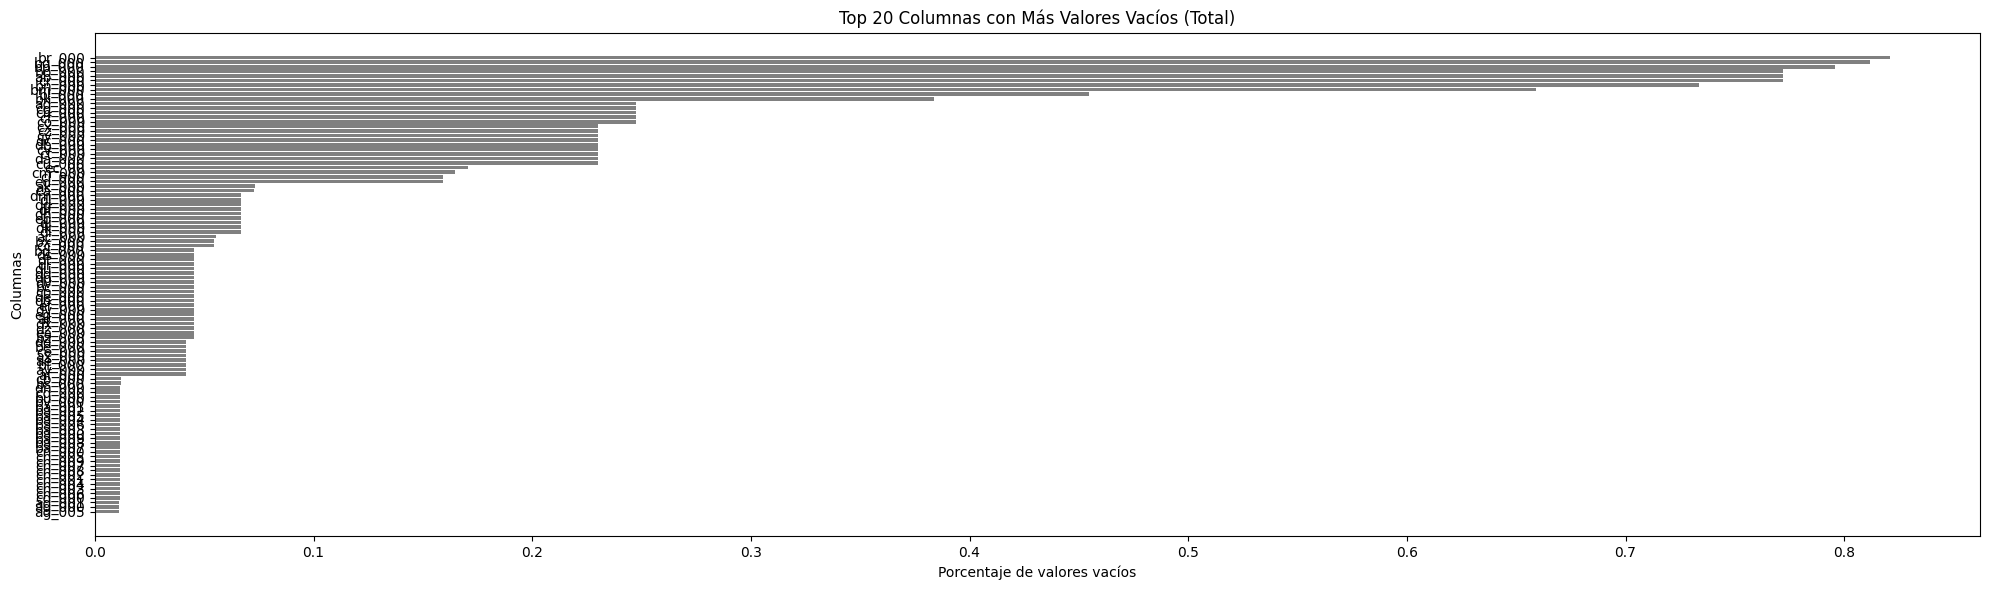

In [301]:
cv = (df == "na").sum()/len(df)

top = cv.sort_values(ascending=False).head(100)

plt.figure(figsize=(20, 6))
plt.barh(top.index[::-1], top.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 20 Columnas con Más Valores Vacíos (Total)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

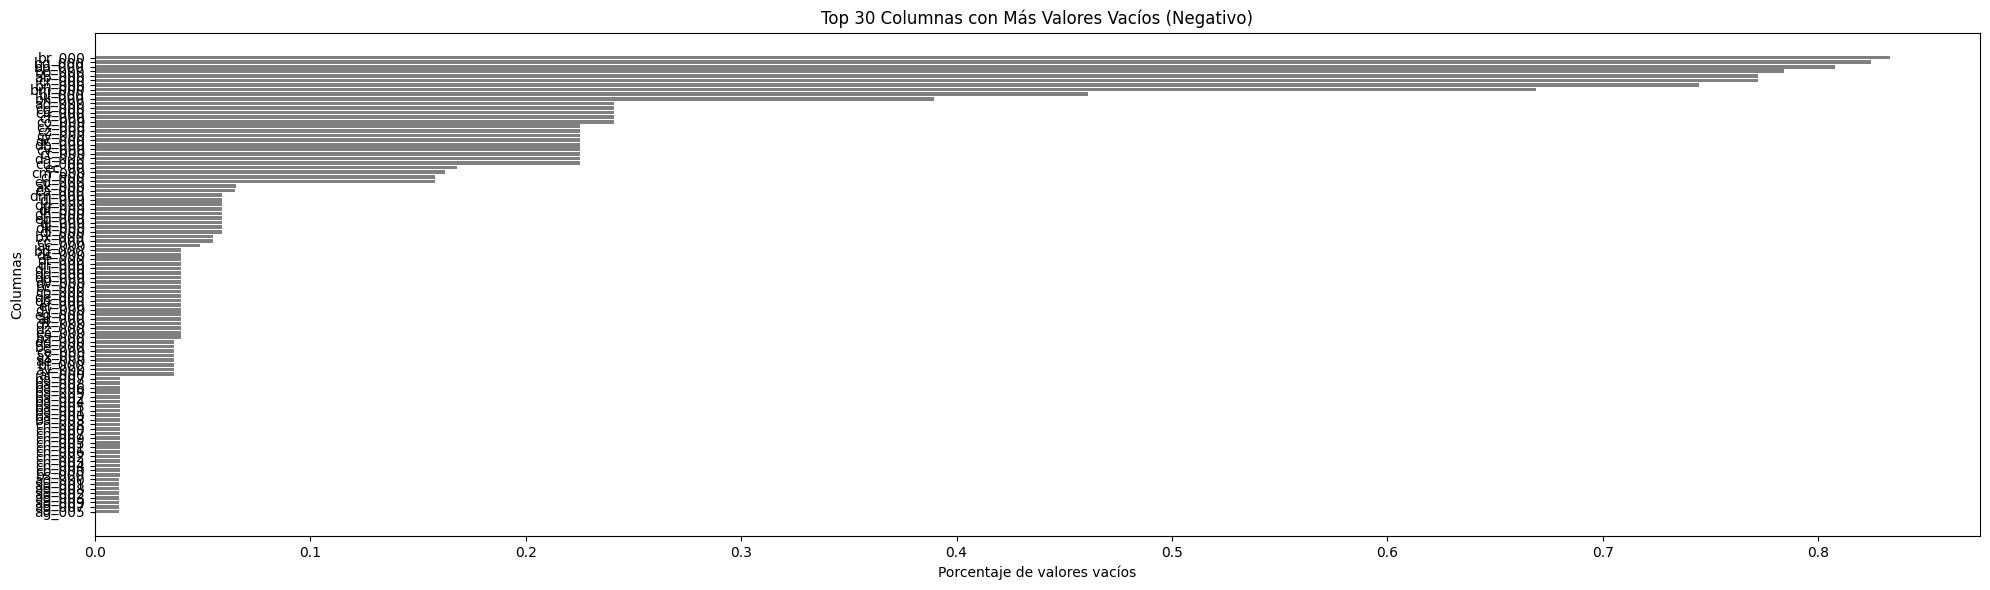

In [302]:
cv_neg = (df_neg == "na").sum()/cant_neg

top_neg = cv_neg.sort_values(ascending=False).head(100)

plt.figure(figsize=(20, 6))
plt.barh(top_neg.index[::-1], top_neg.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 30 Columnas con Más Valores Vacíos (Negativo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

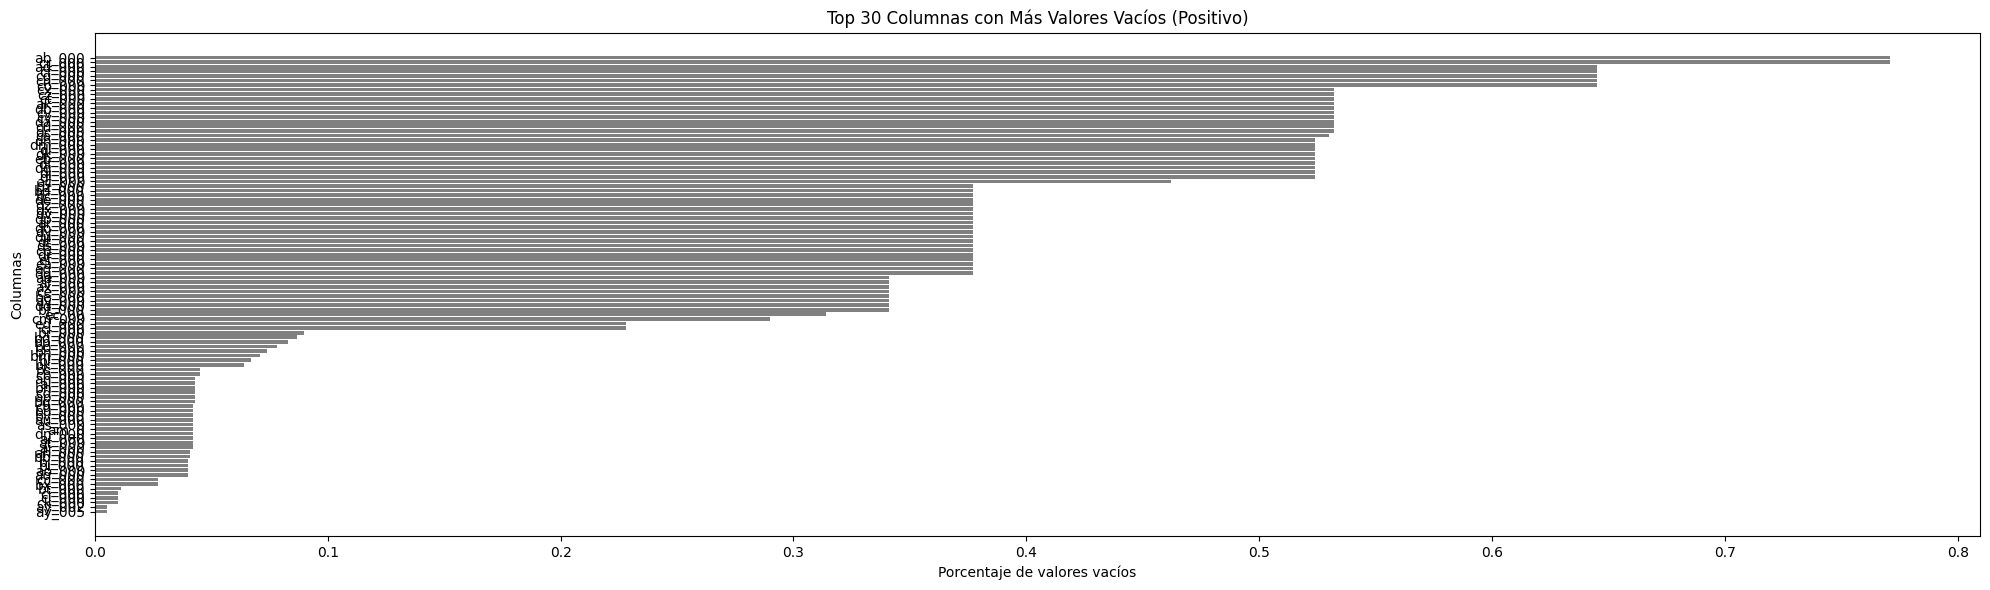

In [303]:
cv_pos = (df_pos == "na").sum()/cant_pos

top_pos = cv_pos.sort_values(ascending=False).head(100)

plt.figure(figsize=(20, 6))
plt.barh(top_pos.index[::-1], top_pos.values[::-1], color='gray')
plt.xlabel('Porcentaje de valores vacíos')
plt.title('Top 30 Columnas con Más Valores Vacíos (Positivo)')
plt.ylabel('Columnas')
plt.tight_layout()
plt.show()

In [304]:
# Columnas con más de 10% de "na"
umbral_total = 0.1
cols_total_umbral = cv[cv > umbral_total].index.tolist()
print("Columnas totales:")
print(cols_total_umbral)

# Columnas con más de 10% de "na"
umbral_pos = 0.1
cols_pos_umbral = cv_pos[cv_pos > umbral_pos].index.tolist()
print("Columnas positivas:")
print(cols_pos_umbral)

# Columnas con más de 10% de "na"
umbral_neg = 0.1
cols_neg_umbral = cv_neg[cv_neg > umbral_neg].index.tolist()
print("Columnas negativas:")
print(cols_neg_umbral)

Columnas totales:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'ec_00', 'ed_000']
Columnas positivas:
['ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ak_000', 'ar_000', 'av_000', 'ax_000', 'bc_000', 'bd_000', 'be_000', 'bf_000', 'bz_000', 'ca_000', 'ce_000', 'cf_000', 'cg_000', 'ch_000', 'cl_000', 'cm_000', 'co_000', 'cp_000', 'cr_000', 'ct_000', 'cu_000', 'cv_000', 'cx_000', 'cy_000', 'cz_000', 'da_000', 'db_000', 'dc_000', 'dd_000', 'de_000', 'df_000', 'dg_000', 'dh_000', 'di_000', 'dj_000', 'dk_000', 'dl_000', 'dm_000', 'do_000', 'dp_000', 'dq_000', 'dr_000', 'ds_000', 'dt_000', 'du_000', 'dv_000', 'dx_000', 'dy_000', 'dz_000', 'ea_000', 'eb_000', 'ec_00', 'ed_000', 'ef_000', 'eg_000']
Columnas negativas:
['ab_000', 'ad_000', 'bk_000', 'bl_000', 'bm_000', 'bn_000', '

In [305]:
cols_eliminar = list(set(cols_total_umbral + cols_pos_umbral + cols_neg_umbral))
df_clean = df.drop(columns=cols_eliminar)

print(df_clean.head(5))

  clase  aa_000 ag_000 ag_001 ag_002 ag_003 ag_004   ag_005   ag_006   ag_007  \
0   neg   76698      0      0      0      0  37250  1432864  3664156  1007684   
1   neg   33058      0      0      0      0  18254   653294  1720800   516724   
2   neg   41040      0      0      0      0   1648   370592  1883374   292936   
3   neg      12      0      0      0    318   2212     3232     1872        0   
4   neg   60874      0      0      0      0  43752  1966618  1800340   131646   

   ...  ee_000   ee_001   ee_002  ee_003  ee_004  ee_005  ee_006  ee_007  \
0  ...  965866  1706908  1240520  493384  721044  469792  339156  157956   
1  ...  664504   824154   421400  178064  293306  245416  133654   81140   
2  ...  262032   453378   277378  159812  423992  409564  320746  158022   
3  ...    5670     1566      240      46      58      44      10       0   
4  ...  404740   904230   622012  229790  405298  347188  286954  311560   

   ee_008 ee_009  
0   73224      0  
1   97576   1500  

In [306]:
df_clean["clase"] = df_clean["clase"].map({"neg": 0, "pos": 1})
print(df_clean.head(5))

   clase  aa_000 ag_000 ag_001 ag_002 ag_003 ag_004   ag_005   ag_006  \
0      0   76698      0      0      0      0  37250  1432864  3664156   
1      0   33058      0      0      0      0  18254   653294  1720800   
2      0   41040      0      0      0      0   1648   370592  1883374   
3      0      12      0      0      0    318   2212     3232     1872   
4      0   60874      0      0      0      0  43752  1966618  1800340   

    ag_007  ...  ee_000   ee_001   ee_002  ee_003  ee_004  ee_005  ee_006  \
0  1007684  ...  965866  1706908  1240520  493384  721044  469792  339156   
1   516724  ...  664504   824154   421400  178064  293306  245416  133654   
2   292936  ...  262032   453378   277378  159812  423992  409564  320746   
3        0  ...    5670     1566      240      46      58      44      10   
4   131646  ...  404740   904230   622012  229790  405298  347188  286954   

   ee_007  ee_008 ee_009  
0  157956   73224      0  
1   81140   97576   1500  
2  158022   95128

In [307]:
df_clean = df_clean.replace("na", np.nan)

In [308]:
df_clean_neg = df_clean[df_clean['clase'] == 0]
df_clean_pos = df_clean[df_clean['clase'] == 1]

# **Dataframe test**

In [309]:
test.rename(columns={'class': 'clase'}, inplace=True)
test_clean = test.drop(columns=cols_eliminar)
test_clean["clase"] = test_clean["clase"].map({"neg": 0, "pos": 1})
test_clean = test_clean.replace("na", np.nan)
print(test_clean.head(5))

   clase  aa_000 ag_000 ag_001 ag_002  ag_003   ag_004   ag_005   ag_006  \
0      0      60      0      0      0    2682     4736     3862     1846   
1      0      82      0      0      0       0      748    12594     3636   
2      0   66002      0      0      0  199486  1358536  1952422   452706   
3      0   59816      0      0      0       0   123922   984314  1680050   
4      0    1814      0      0      0       0       72    17926    82834   

    ag_007  ...  ee_000  ee_001  ee_002  ee_003  ee_004  ee_005   ee_006  \
0        0  ...    7502    3156    1098     138     412     654       78   
1        0  ...   10040    3310    1068     276    1620     116       86   
2    25130  ...  396312  538136  495076  380368  440134  269556  1315022   
3  1135268  ...  659550  691580  540820  243270  483302  485332   431376   
4     3114  ...   10216    9958    7646    4144   18466   49782     3176   

   ee_007  ee_008 ee_009  
0      88       0      0  
1     462       0      0  
2  15

# **Entrenamiento del modelo**

In [310]:
x_train = df_clean.drop(columns=['clase'])
y_train = df_clean['clase']
x_test = test_clean.drop(columns=['clase'])
y_test = test_clean['clase']

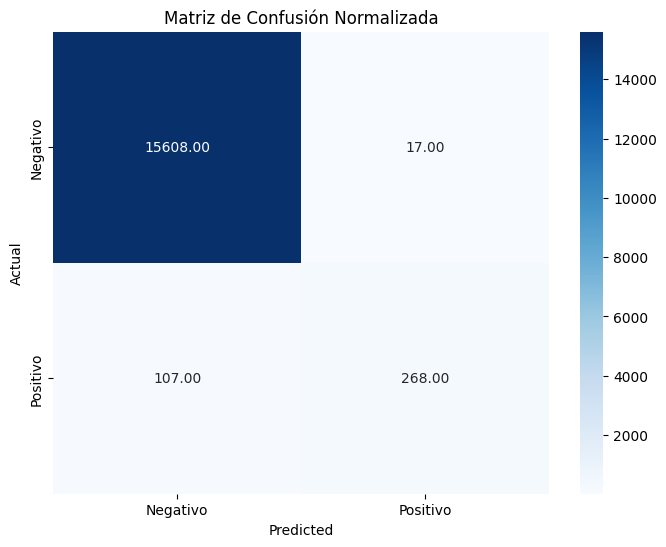

Accuracy: 0.9922
Precision: 0.9404
Recall: 0.7147
F1-score: 0.8121


In [311]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Inicialización y entrenamiento del modelo
model = RandomForestClassifier(random_state=100)
model.fit(x_train, y_train)

# Predicciones sobre el conjunto de prueba
y_pred = model.predict(x_test)

# Cálculo de la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualización de la matriz de confusión normalizada
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Negativo', 'Positivo'], yticklabels=['Negativo', 'Positivo'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Matriz de Confusión Normalizada')
plt.show()

# Cálculo e impresión de otras métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")